# LangGraph 测试Notebook
---
目标：验证 LangGraph `StateGraph` 基础流转，建立 `GlobalState` 定义与各层节点骨架。

该Notebook是另外一个的改写，只保留真正实现了的逻辑。

In [1]:
# ── 依赖安装 ──────────────────────────────────────────────────────────────────
%pip install -q python-dotenv
%pip install -qU langchain-core langchain-ollama
%pip install -qU langgraph
%pip install -qU langchain-anthropic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ---- Environment & Logging Init -----------------------------------------------
import os, sys, queue as _queue_module
# Jupyter notebooks don't define __file__, so locate the project root by
# searching upward for CLAUDE.md (the project marker file).
def _find_project_root(marker: str = "CLAUDE.md") -> str:
    path = os.path.abspath("")
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        path = os.path.dirname(path)
    raise RuntimeError(f"Project root not found (searched for '{marker}')")

_root = _find_project_root()
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Project root:", _root)
import getpass
import logging
from dotenv import load_dotenv

from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END

from langchain.agents import create_agent
from pydantic import BaseModel, Field
from SkiLib.metatools.informative import get_tools as get_info_tools
from SkiLib.registry import SkillRegistry

# Load env vars + optional LangSmith tracing
load_dotenv()
if os.getenv("LANGSMITH_TRACING", "false").lower() == "true":
    if not os.getenv("LANGSMITH_API_KEY"):
        os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter LangSmith API Key: ")
    if not os.getenv("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = getpass.getpass("Enter LangSmith Project name: ")

logging.basicConfig(level=logging.ERROR, force=True)

# --- Real-time log streaming setup -------------------------------------------
# log_queue is consumed by the Gradio UI (or any UI layer) for live display.
# attach_queue_handler() lives entirely in stdlib; no LangGraph dependency.
from SkiLib.log import get_logger, attach_queue_handler

log_queue: _queue_module.Queue = _queue_module.Queue()
attach_queue_handler(log_queue)

# Notebook-level logger (used by node functions defined in this notebook)
logger = get_logger("graph_test")

print("Environment loaded. LangSmith tracing:", os.getenv("LANGSMITH_TRACING", "false"))
print("log_queue ready:", log_queue)

Project root: d:\code\skiagent\RoboSkiAgent
Environment loaded. LangSmith tracing: false
log_queue ready: <queue.Queue object at 0x000001A5F857E750>


In [3]:
LLM_TYPE = "claude"  # 可选 "claude" 或 "ollama"（本地）
# ── LLM 配置 ──────────────────────────────────────────────────────────────────
# 使用本地 Ollama 时修改 OLLAMA_MODEL_ID 切换模型
OLLAMA_MODEL_ID = os.getenv("OLLAMA_MODEL_ID", "qwen3:latest")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

if LLM_TYPE == "claude":
    llm = ChatAnthropic(
        model="claude-sonnet-4-6"
    )
else:
    llm = ChatOllama(
        model=OLLAMA_MODEL_ID,
        base_url=OLLAMA_BASE_URL,
        temperature=0,
    )

# 快速连通性检查
try:
    _ping = llm.invoke("Reply with one word: ready")
    print("LLM reachable:", _ping.content.strip()[:80])
except Exception as e:
    print(f"[WARN] LLM not reachable — nodes using llm will fail. ({e})")

LLM reachable: ready


## GlobalState
与 `CLAUDE.md` 中 `GlobalState` 规范保持一致。  
`robot_state` 此处用 `dict` 代替，生产版本从 `SkiLib.base` 导入 `RobotState`。

In [4]:
# ── GlobalState 定义 ──────────────────────────────────────────────────────────
from typing import TypedDict, Annotated, Optional, Literal
import operator
from SkiLib.base import SkillResult


class GlobalState(TypedDict):
    # Layer-1：规划层输出
    todo_list: list[dict]           # [{task_id, type, skill/description, params}, ...]

    # Layer-2：执行上下文
    current_task: dict              # 执行槽：{} = 空闲，{...} = 执行中或失败保留

    # 机器人运行时快照（此处用 dict 代替，生产类型：SkiLib.base.RobotState）
    robot_state: dict

    # 控制标志
    halt_flag: bool                 # True = 所有 R-skill 执行被锁定
    halt_reason: Optional[str]      # "TASK_FAILURE" | "MANUAL_TASK" | None

    # Executor 写入；含 needs_hitl 字段供 Context Flush 决策
    last_result: Optional[SkillResult]

    plan_review_action: Optional[Literal["approve", "replan", "abort"]]
    
    # 内部路由字段：HumanIntervention的结果, = "complete" | "abort"
    intervention_action: Optional[str]

    # 解耦出的单独在HITL结束后的action， = "retry" | "next_task" | "replan" | "abort"
    hitl_command: Optional[str]

    # 审计日志，由 Context Flush 写入；Annotated list 避免键覆盖
    execution_log: Annotated[list[str], operator.add]

    # LangGraph 消息总线
    # TODO:这个职责边界还是不清晰，llm也改烂了
    messages: Annotated[list[BaseMessage], operator.add]


print("GlobalState keys:", list(GlobalState.__annotations__.keys()))


GlobalState keys: ['todo_list', 'current_task', 'robot_state', 'halt_flag', 'halt_reason', 'last_result', 'plan_review_action', 'intervention_action', 'hitl_command', 'execution_log', 'messages']


In [5]:
# ---- Node: Supervisor ----------------------------------------------------------
from langchain.agents import create_agent
from pydantic import BaseModel, Field
from SkiLib.metatools.informative import get_tools as get_info_tools
from SkiLib.registry import SkillRegistry


# ---- SupervisorOutput Schema ---------------------------------------------------
class SupervisorOutput(BaseModel):
    """Fact sheet produced after knowledge saturation. Symbol-only, no coordinates."""
    task_intent_original: str = Field(description="Verbatim user instruction")
    task_intent: str = Field(
        description="Rewritten instruction using exact RoboDK symbol names"
    )
    scene: dict = Field(
        description="Keys: targets (list[str]), objects (list[str]), tools (list[str])"
    )
    # available_skills: injected by code, not filled by LLM
    extra_info: str = Field(
        default="",
        description="Unresolvable ambiguities or free-text observations"
    )


def _get_available_skills() -> dict:
    """Pure-code: read skill signatures from SkillRegistry. No LLM involved."""
    registry = SkillRegistry.instance()
    if not registry:
        return {}
    return {
        name: registry.get_skill(name).execute.__doc__ or ""
        for name in registry.list_skills()
    }


def _build_supervisor_prompt() -> str:
    skills_text = "\n".join(
        f"  - {name}: {doc.strip()}"
        for name, doc in _get_available_skills().items()
    ) or "  (none registered)"

    return f"""\
You are the Supervisor agent in an industrial robot assembly system.

Your ONLY job: gather scene facts and produce a structured SupervisorOutput summary.
Do NOT plan tasks, choose skills, or compute coordinates.

Rules:
- Call tools to query the RoboDK scene until you have enough information.
- Rewrite the instruction in `task_intent` using exact RoboDK symbol names
  and exact skill names (e.g. "Part_A_1", not "part A").
- All `scene` fields must use exact names returned by query tools — no invented names.
- Never include coordinates, joint angles, or numeric poses anywhere in your output.
- Record unresolvable ambiguities in `extra_info` instead of guessing.

Available skills (for your reference only — do not invent new ones):
{skills_text}
"""


# ---- Lazy singleton ------------------------------------------------------------
_supervisor_agent = None

def _get_supervisor_agent():
    global _supervisor_agent
    if _supervisor_agent is None:
        _supervisor_agent = create_agent(
            model=llm,
            tools=get_info_tools(),
            response_format=SupervisorOutput,
            system_prompt=_build_supervisor_prompt(),
        )
        logger.info("[supervisor] Agent built. Skills: %s", list(_get_available_skills().keys()))
    return _supervisor_agent


# ---- Node function -------------------------------------------------------------
def supervisor(state: GlobalState) -> dict:
    logger.info("[supervisor] Starting knowledge saturation...")
    result = _get_supervisor_agent().invoke({"messages": state["messages"]})

    summary: SupervisorOutput | None = result.get("structured_response")
    if summary is None:
        raw = state["messages"][-1].content
        raw_str = raw if isinstance(raw, str) else str(raw)
        summary = SupervisorOutput(
            task_intent_original=raw_str,
            task_intent=raw_str,
            scene={},
            extra_info="response_format unsupported — stub fallback",
        )
        logger.warning("[supervisor] structured_response missing, using stub fallback")

    output = summary.model_dump()
    output["available_skills"] = _get_available_skills()

    logger.info("[supervisor] Done. Intent: %s | Scene: %s", summary.task_intent, summary.scene)

    return {
        "messages":      [AIMessage(content=str(output))],  # Planner reads this
        "execution_log": [f"[supervisor] {summary.task_intent}"],
    }


print("Supervisor cell loaded.")

Supervisor cell loaded.


In [6]:
# ── Supervisor 单元测试 ───────────────────────────────────────────────────────
# 前提：RoboDK 已启动
from SkiLib.robotcontext import RobotContext
from SkiLib.registry import SkillRegistry
import json
# 1. 拉起 RoboDK API
context = RobotContext()
RDK    = context.RDK
robot  = context.robot
skill_registry = SkillRegistry.instance()
print("[init] RobotContext OK, skills:", skill_registry.list_skills())

# 2. 重置 supervisor 单例（使其用已初始化的 SkillRegistry 重建）
_supervisor_agent = None

# 3. 构造最小初始状态
_test_state = {
    "messages":      [HumanMessage(content="把 Part_A_1 放到 Place Part A")],
    "todo_list":     [], "current_task": {}, "robot_state": {},
    "halt_flag":     False, "halt_reason": None,
    "last_result":   None, "_hi_action":  None, "execution_log": [],
}

# 4. 运行
print("\n[test] Running supervisor...")
_updates = supervisor(_test_state)

# 5. 解析输出
_out = _updates["messages"][-1].content

2026-03-27 16:23:35,082 [INFO] SkiLib.registry — SkillRegistry: registered 'DummySkill'
2026-03-27 16:23:35,083 [INFO] SkiLib.registry — SkillRegistry: registered 'PickAndPlace'
2026-03-27 16:23:35,084 [INFO] graph_test — [supervisor] Starting knowledge saturation...
2026-03-27 16:23:35,090 [INFO] graph_test — [supervisor] Agent built. Skills: ['DummySkill', 'PickAndPlace']


[PrimitiveRegistry] Registered: Grasp
[PrimitiveRegistry] Registered: Release
[PrimitiveRegistry] Registered: MoveJ
[PrimitiveRegistry] Registered: MoveL
[DummySkill] __init__ called. Received primitives: ['Grasp', 'Release', 'MoveJ', 'MoveL']
[init] RobotContext OK, skills: ['DummySkill', 'PickAndPlace']

[test] Running supervisor...


2026-03-27 16:23:48,324 [INFO] graph_test — [supervisor] Done. Intent: 使用 PickAndPlace 技能，将工件 Part_A_1 从 Pick Part A（接近点：App Pick Part A）拾取，放置到 Place Part A（接近点：App Place Part A），工具为 Gripper Extension。 | Scene: {'targets': ['Pick Part A', 'App Pick Part A', 'Place Part A', 'App Place Part A '], 'objects': ['Part_A_1'], 'tools': ['Gripper Extension']}


In [7]:
_out

'{\'task_intent_original\': \'把 Part_A_1 放到 Place Part A\', \'task_intent\': \'使用 PickAndPlace 技能，将工件 Part_A_1 从 Pick Part A（接近点：App Pick Part A）拾取，放置到 Place Part A（接近点：App Place Part A），工具为 Gripper Extension。\', \'scene\': {\'targets\': [\'Pick Part A\', \'App Pick Part A\', \'Place Part A\', \'App Place Part A \'], \'objects\': [\'Part_A_1\'], \'tools\': [\'Gripper Extension\']}, \'extra_info\': \'夹爪当前未抓取任何物体（grasped: []），可直接执行拾取操作。注意 "App Place Part A " 名称末尾含有一个空格，调用时需保持原名。\', \'available_skills\': {\'DummySkill\': \'Execute the dummy skill. Does nothing except log and return success.\', \'PickAndPlace\': \'\\n        Execute pick and place.\\n\\n        Args:\\n            item:            RoboDK name of the workpiece.\\n            pick_approach:   Approach/depart point near the pick location.\\n            pick_target:     Precise grasp point (MoveL).\\n            place_approach:  Approach/depart point near the place location.\\n            place_target:    Precise place point (

In [8]:
#测试工具生成
skill_registry.get_tools()

[StructuredTool(name='DummySkill_check', description='Check that the dummy skill is reachable. message is echoed back in data.', args_schema=<class 'langchain_core.utils.pydantic.DummySkill_check'>, func=<function DummySkill.check at 0x000001A5FA2CD6C0>),
 StructuredTool(name='DummySkill_try_execute', description='Run check then execute. Aborts on check failure.', args_schema=<class 'langchain_core.utils.pydantic.DummySkill_try_execute'>, func=<function DummySkill.try_execute at 0x000001A5FA2CCA40>),
 StructuredTool(name='PickAndPlace_check', description='Pre-flight feasibility check.\n\n        Args:\n            item:            RoboDK name of the workpiece to grasp/release.\n            pick_approach:   Target name for the approach/depart point near pick.\n            pick_target:     Target name for the linear-move precise grasp point.\n            place_approach:  Target name for the transit destination / depart point near place.\n            place_target:    Target name for the l

In [ ]:
# ---- Node: Planner (tool-call version) ----------------------------------------
from pydantic import BaseModel, Field
from typing import Literal, Annotated, Union
from langchain_core.tools import StructuredTool
from langchain.agents import create_agent


# ---- Task models ---------------------------------------------------------------
class AutoTask(BaseModel):
    task_id: str
    type: Literal["auto"] = "auto"
    skill: str
    params: dict

class ManualTask(BaseModel):
    task_id: str
    type: Literal["manual"] = "manual"
    description: str

Task = Annotated[Union[AutoTask, ManualTask], Field(discriminator="type")]

class PlannerOutput(BaseModel):
    todo_list: list[Task]


# ---- Dynamic tool generation ---------------------------------------------------
def _make_planner_tools(registry) -> tuple[list[StructuredTool], list[dict]]:
    """
    For each Skill, generate an add_<SkillName>_task tool reusing try_execute's
    args_schema. task_id is auto-assigned; LLM only fills skill parameters.
    """
    plan: list[dict] = []
    tools: list[StructuredTool] = []

    for skill_name in (registry.list_skills() if registry else []):
        skill = registry.get_skill(skill_name)
        try_exec = next(
            (t for t in skill.as_tools() if t.name.endswith("_try_execute")), None
        )
        if try_exec is None or try_exec.args_schema is None:
            continue

        def _create_task_adder(sname: str):
            def _add_task(**kwargs) -> str:
                task_id = f"t{len(plan) + 1}"
                plan.append({"task_id": task_id, "type": "auto", "skill": sname, "params": kwargs})
                return f"Task {task_id} ({sname}) added. Plan so far: {len(plan)} task(s)."
            return _add_task

        tools.append(StructuredTool(
            name=f"add_{skill_name}_task",
            description=f"Add a {skill_name} task. " + (try_exec.description or "").splitlines()[0],
            func=_create_task_adder(skill_name),
            args_schema=try_exec.args_schema,
        ))

    # Manual task tool
    class AddManualTaskSchema(BaseModel):
        description: str = Field(description="What the human operator needs to do")

    def _add_manual(description: str) -> str:
        task_id = f"t{len(plan) + 1}"
        plan.append({"task_id": task_id, "type": "manual", "description": description})
        return f"Manual task {task_id} added."

    tools.append(StructuredTool.from_function(
        func=_add_manual,
        name="add_manual_task",
        description="Add a manual human-intervention step to the plan.",
        args_schema=AddManualTaskSchema,
    ))

    return tools, plan


_PLANNER_SYSTEM_PROMPT = """\
You are the planner of a symbolic robot assembly system.
Build a task plan by calling the provided tools — one call per task, in order.

Rules:
- The system will always let human review the whole plan, so no need to add extra manual review tasks.
- Use ONLY exact symbol names from the scene in the user message — never invent names.
- Fill ALL required parameters (those without a default in the tool signature).
- Use add_manual_task when it's requested by human for intervention, or you have found
    a step cannot be done by any provided tool.
- When done, stop calling tools. Do not output any JSON yourself.
"""


# ---- Node function -------------------------------------------------------------
def planner(state: GlobalState) -> dict:
    logger.info("[planner] Building plan via tool calls...")
    registry = SkillRegistry.instance()
    tools, plan = _make_planner_tools(registry)

    agent = create_agent(model=llm, tools=tools, system_prompt=_PLANNER_SYSTEM_PROMPT)

    # Supervisor output is the last AIMessage; wrap as HumanMessage for Anthropic
    sup_content = state["messages"][-1].content
    agent.invoke({"messages": [HumanMessage(content=sup_content)]})

    manual_count = sum(1 for t in plan if t["type"] == "manual")
    logger.info("[planner] Done: %d tasks (%d manual)", len(plan), manual_count)

    return {
        "todo_list":     plan,
        "execution_log": [f"[planner] {len(plan)} tasks queued ({manual_count} manual): "
                          + ", ".join(t.get("skill") or t.get("description", "?") for t in plan)],
    }


print("Planner cell loaded.")

Planner cell loaded.


In [10]:
# ========== plan_review 节点 ==========
# 弃用模型生成手动任务，现在结构上直接过这个节点，review并可以输入消息重新返回supervisor进行规划。
# 手动任务的职责简化为handle机器人处理不了的task。
from langgraph.types import interrupt
def plan_review(state: GlobalState) -> dict:
    logger.info("[plan_review] Reviewing plan... ")
    plan_summary = "\n".join(
    f"  {t['task_id']} [{t['type']}] "
    + (t.get('skill', '') + str(t.get('params', {})) if t['type'] == 'auto' else t.get('description', ''))
    for t in state.get("todo_list", [])
    
    
)
    # 通过Gradio输入框让用户决定是否重新规划
    result = interrupt({
        "options": ["approve", "replan", "abort"],
        "description": f"Generated plan:\n{plan_summary}"
    })
    if isinstance(result, dict):          # replan path
        command  = result.get("action")
        feedback = result.get("feedback", "")
    else:                                  # approve / abort
        command  = result
        feedback = ""
    return_state = {
        "execution_log": ["[plan_review] Plan reviewed result: {command}"],
        "plan_review_action": command
    }
    if command == "replan":
        return_state['messages'] = [HumanMessage(content=f"Please replan based on human feedback: {feedback}")]
        return_state['todo_list'] = []  # Clear the current plan to trigger re-planning
    return return_state

def plan_review_router(state: GlobalState) -> str:
    action = state.get("plan_review_action")
    if action == "approve":
        return "approve"
    elif action == "replan":
        return "replan"
    else:
        return "END"
    

In [11]:
# ── Planner 工具生成单元测试 ──────────────────────────────────────────────────
# 前提：RobotContext 已初始化（复用上方 cell 的 context）
from SkiLib.registry import SkillRegistry

registry = SkillRegistry.instance()
tools, _ = _make_planner_tools(registry)

print("Generated planner tools:")
for t in tools:
    schema = t.args_schema
    fields = list(schema.model_fields.keys()) if schema else None
    print(f"  {t.name}")
    print(f"    args_schema : {schema}")
    print(f"    fields      : {fields}")
    print()

auto_tools  = [t for t in tools if t.name != "add_manual_task"]
skill_names = registry.list_skills()

print(f"Registered skills : {skill_names}")
print(f"Auto tools found  : {[t.name for t in auto_tools]}")
print()

# 验证每个 skill 都有对应的 add_<SkillName>_task 工具
missing = [s for s in skill_names if f"add_{s}_task" not in [t.name for t in tools]]
if missing:
    print(f"[FAIL] Skills with no tool generated (args_schema likely None): {missing}")
else:
    print(f"[PASS] All {len(skill_names)} skill(s) have a corresponding add_<SkillName>_task tool.")

# 验证每个 auto tool 的 args_schema 非空
no_schema = [t.name for t in auto_tools if t.args_schema is None]
if no_schema:
    print(f"[FAIL] Tools with args_schema=None: {no_schema}")
else:
    print(f"[PASS] All auto tool(s) have a valid args_schema.")


Generated planner tools:
  add_DummySkill_task
    args_schema : <class 'langchain_core.utils.pydantic.DummySkill_try_execute'>
    fields      : ['message']

  add_PickAndPlace_task
    args_schema : <class 'langchain_core.utils.pydantic.PickAndPlace_try_execute'>
    fields      : ['item', 'pick_approach', 'pick_target', 'place_approach', 'place_target', 'transit_motion', 'initial_motion']

  add_manual_task
    args_schema : <class '__main__._make_planner_tools.<locals>.AddManualTaskSchema'>
    fields      : ['description']

Registered skills : ['DummySkill', 'PickAndPlace']
Auto tools found  : ['add_DummySkill_task', 'add_PickAndPlace_task']

[PASS] All 2 skill(s) have a corresponding add_<SkillName>_task tool.
[PASS] All auto tool(s) have a valid args_schema.


In [12]:
# ── Planner 单元测试 ──────────────────────────────────────────────────────────
# 前提：RobotContext 已初始化（复用 supervisor 测试单元格中的 context）
# 直接从 RoboDK scene 查询真实符号名，不使用 mock

import json
from SkiLib.metatools.informative import list_targets, list_objects, list_tools

# 1. 从真实 scene 获取符号名
_real_targets = list_targets.invoke({})
_real_objects = list_objects.invoke({})
_real_tools   = list_tools.invoke({})
print("[scene] targets:", _real_targets)
print("[scene] objects:", _real_objects)
print("[scene] tools:  ", _real_tools)

# 2. 构造用户指令（使用 scene 里真实存在的第一个 object）
if not _real_objects:
    raise RuntimeError("No objects in RoboDK scene — cannot run Planner test.")
_test_object = "Part_A_1"
_user_instruction = f"把 {_test_object} 放到对应的放置点"

# 3. 构造 SupervisorOutput（task_intent 使用真实符号名，scene 来自真实查询）
#    _build_planner_prompt() 已经从 SkillRegistry 注入完整参数 schema，
#    这里不再需要 available_skills 字段。
_real_sup_output = json.dumps({
    "task_intent_original": _user_instruction,
    "task_intent": f"Pick {_test_object} and place it at the corresponding place target.",
    "scene": {
        "targets": _real_targets,
        "objects": _real_objects,
        "tools":   _real_tools,
    },
    "extra_info": "",
}, ensure_ascii=False, indent=2)

print("\n[SupervisorOutput passed to Planner]\n", _real_sup_output)

# 4. 构造 planner 入参 state
_planner_test_state = {
    "messages": [
        HumanMessage(content=_user_instruction),
        AIMessage(content=_real_sup_output),   # planner 读取 messages[-1]
    ],
    "todo_list": [], "current_task": {}, "robot_state": {},
    "halt_flag": False, "halt_reason": None,
    "last_result": None, "_hi_action": None, "execution_log": [],
}

# 5. 运行
print("\n[test] Running planner...")
_plan_updates = planner(_planner_test_state)

# 6. 打印结果
print("\n[PlannerOutput]")
for t in _plan_updates["todo_list"]:
    if t["type"] == "auto":
        print(f"  [{t['task_id']}] AUTO  skill={t['skill']}  params={t['params']}")
    else:
        print(f"  [{t['task_id']}] MANUAL  desc={t['description']!r}")

# 7. 验证：auto task 的 params 必须非空
auto_tasks = [t for t in _plan_updates["todo_list"] if t["type"] == "auto"]
empty_params = [t for t in auto_tasks if not t["params"]]
if empty_params:
    print(f"\n[FAIL] {len(empty_params)} auto task(s) have empty params: {[t['task_id'] for t in empty_params]}")
else:
    print(f"\n[PASS] All {len(auto_tasks)} auto task(s) have non-empty params.")

# 8. Pydantic 二次验证
_validated = PlannerOutput(todo_list=_plan_updates["todo_list"])
print(f"[PASS] Pydantic validation OK ({len(_validated.todo_list)} tasks)")


2026-03-27 16:23:48,393 [INFO] graph_test — [planner] Building plan via tool calls...


[scene] targets: ['Pick Part A New', 'Home A', 'Place Part A', 'App Place Part A ', 'App Pick Part A', 'Pick Part A', 'Pick Part B', 'App Pick Part B', 'App Place Part B', 'Place Part B', 'Home B', 'Pick Part C', 'App Pick Part C', 'Place Part C', 'App Place Part C', 'Home C', 'Target 6']
[scene] objects: ['Base Cylinder', 'New Table Actual', 'New Table Actual-22', 'New Table Actual-21', 'New Table Actual-20', 'New Table Actual-43', 'New Table Actual-44', 'New Table Actual-45', 'New Table Actual-40', 'New Table Actual-52', 'New Table Actual-53', 'Part_A_1', 'Part_A_2', 'Part_B_1', 'Part_B_2', 'Part_C_1', 'Part_C_2']
[scene] tools:   ['Gripper Extension']

[SupervisorOutput passed to Planner]
 {
  "task_intent_original": "把 Part_A_1 放到对应的放置点",
  "task_intent": "Pick Part_A_1 and place it at the corresponding place target.",
  "scene": {
    "targets": [
      "Pick Part A New",
      "Home A",
      "Place Part A",
      "App Place Part A ",
      "App Pick Part A",
      "Pick Part A",

2026-03-27 16:24:02,455 [INFO] graph_test — [planner] Done: 2 tasks (1 manual)



[PlannerOutput]
  [t1] MANUAL  desc="Please review the full task plan before execution:\n1. Pick Part_A_1 from 'Pick Part A' (approach: 'App Pick Part A'), and place it at 'Place Part A' (approach: 'App Place Part A ').\nVerify that all target positions, approach paths, and the part location are correct before proceeding."
  [t2] AUTO  skill=PickAndPlace  params={'item': 'Part_A_1', 'pick_approach': 'App Pick Part A', 'pick_target': 'Pick Part A', 'place_approach': 'App Place Part A ', 'place_target': 'Place Part A', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'}

[PASS] All 1 auto task(s) have non-empty params.
[PASS] Pydantic validation OK (2 tasks)


In [13]:
# ---- Node: Dispatcher (pure code, no LLM) -------------------------------------
def dispatcher(state: GlobalState) -> dict:
    current = state.get("current_task")
    if current and current.get("task_id") is not None:
        logger.info("[dispatcher] Slot occupied: %s, skip pop", current["task_id"])
        return {}
    if not state.get("todo_list"):
        logger.info("[dispatcher] No tasks in todo_list")
        return {}

    next_task = state["todo_list"][0]
    label = next_task.get("skill") or next_task.get("description", "?")
    logger.info("[dispatcher] Dispatching %s (%s): %s",
                next_task["task_id"], next_task["type"], label)

    updates: dict = {
        "current_task": next_task,
        "todo_list":    state["todo_list"][1:],
        "execution_log": [f"[dispatcher] {next_task['task_id']} ({next_task['type']}): {label}"],
    }

    # Manual tasks: set halt so after_dispatcher routes to manual_intervention_handler
    if next_task["type"] == "manual":
        updates["halt_flag"]   = True
        updates["halt_reason"] = "MANUAL_TASK"

    return updates


def task_router(state: GlobalState) -> str:
    current = state.get("current_task")
    if not current or current.get("task_id") is None:
        return "END"
    return current["type"]  # "auto" or "manual"

In [14]:
# ---- Node: ManualInterventionHandler ------------------------------------------
from langgraph.types import interrupt

def manual_intervention_handler(state: GlobalState) -> dict:
    task = state.get("current_task", {})
    desc = task.get("description", "No description provided for manual task.")
    logger.info("[manual_handler] Waiting for operator: %s", desc)

    command = interrupt({
        "options":     ["complete", "abort"],
        "description": desc,
    })

    if command == "complete":
        logger.info("[manual_handler] %s -> COMPLETE", task.get("task_id"))
        return {
            "current_task":      {},
            "halt_flag":         False,
            "halt_reason":       None,
            "intervention_action": "complete",
            "execution_log":     [f"[manual_handler] {task.get('task_id')} -> COMPLETE"],
        }
    else:  # abort
        logger.info("[manual_handler] %s -> ABORT", task.get("task_id"))
        return {
            "current_task":      {},
            "todo_list":         [],
            "halt_flag":         False,
            "halt_reason":       None,
            "intervention_action": "abort",
            "execution_log":     [f"[manual_handler] {task.get('task_id')} -> ABORT"],
        }


def manual_intervention_router(state: GlobalState) -> str:
    action = state.get("intervention_action")
    if action == "complete":
        return "dispatcher"
    else:
        if action != "abort":
            logger.warning("[manual_intervention_router] Unexpected action '%s', routing to END", action)
        return "END"

In [15]:
# ---- Node: Executor & PostTaskRouter ------------------------------------------
from langchain_core.tools import StructuredTool
from SkiLib.base import ERROR_ROBOT_INACTIVE, SkillResult, ExecutionPhase
from SkiLib.metatools.informative import list_targets


class _EscalateHITLException(Exception):
    def __init__(self, error_type: str, reason: str | None = None, suggestion: str | None = None):
        self.error_type = error_type
        self.reason     = reason
        self.suggestion = suggestion

    def __str__(self):
        return f"HITL escalation: {self.error_type} — {self.reason}"


def _escalate_to_hitl(error_type: str, reason: str | None = None, suggestion: str | None = None):
    """Escalate the current task to human intervention.

    Call this when the error is unrecoverable and automated recovery is not possible.
    Unrecoverable conditions include: hardware failure, IK/reachability failure,
    persistent collision, unknown skill parameters, or any situation where you
    are unsure how to proceed safely.

    Do NOT call this for transient or parameter errors you can fix by retrying
    with corrected arguments.

    Args:
        error_type:  Short error code describing the failure cause.
                     Use one of: 'IK_FAILURE', 'HARDWARE_ERROR', 'COLLISION',
                     'TIMEOUT', 'UNKNOWN_CAUSE', or any ERROR_* constant.
        reason:      Brief explanation of why the error occurred.
        suggestion:  Suggested action for the human supervisor to resolve the error.
    """
    raise _EscalateHITLException(error_type, reason, suggestion)


escalate_tool = StructuredTool.from_function(
    func=_escalate_to_hitl,
    name="escalate_to_hitl",
    description="Escalate the task to human intervention when recovery is not possible.",
    handle_tool_error=False,
)


def _build_executor_prompt(error_info: str) -> str:
    return f"""You are a recovery executor agent in a robot assembly system.
A skill execution failed. Analyze the error and either retry with corrected parameters or escalate.

Rules:
- Only retry if the error is clearly recoverable (e.g., wrong parameter name, transient issue).
- Call escalate_to_hitl if the error is unrecoverable (hardware failure, IK failure, unknown cause).
- Fill in reason and suggestion when escalating to help the human operator.
- Never output JSON or plaintext actions — always use the provided tools.

Error information (result of last execution attempt):
{error_info}
"""


def executor(state: GlobalState) -> dict:
    task = state.get("current_task", {})
    tid  = task.get("task_id", "?")
    skill_name = task.get("skill", "?")

    if state.get("halt_flag"):
        logger.warning("[executor] Halted — skipping %s", tid)
        return {
            "execution_log": [f"[executor] HALTED — skipping {tid}"],
            "last_result": SkillResult(
                success=False,
                execution_phase=ExecutionPhase.EXECUTION,
                error_type=ERROR_ROBOT_INACTIVE,
                message="Robot is halted. Executor skipped task.",
                needs_hitl=True,
            ),
        }

    logger.info("[executor] Running: %s(%s)", skill_name, task.get("params"))

    registry = SkillRegistry.instance()
    skill    = registry.get_skill(skill_name)
    result: SkillResult = skill.try_execute(**task.get("params"))  # type: ignore

    if result.success:
        logger.info("[executor] %s (%s) -> SUCCESS", tid, skill_name)
        return {
            "messages":      [AIMessage(content=f"[{tid}] {skill_name} | SUCCESS")],
            "execution_log": [f"[executor] {tid} {skill_name} -> SUCCESS"],
            "last_result":   result,
            "current_task":  {},  # vacate execution slot
        }

    # First attempt failed — invoke LLM recovery loop
    logger.warning("[executor] %s failed: %s. Starting LLM recovery...", tid, result.error_type)

    executor_tools  = [escalate_tool, *skill.as_tools(), list_targets]
    executor_agent  = create_agent(
        model=llm,
        tools=executor_tools,
        system_prompt=_build_executor_prompt(result.to_llm_message()), #type:ignore
    )

    try:
        executor_agent.invoke({"messages": [HumanMessage(content="Please analyze the failure and decide how to proceed.")]})
    except _EscalateHITLException as e:
        logger.error("[executor] %s escalated to HITL: %s", tid, e.error_type)
        return {
            "messages":      [AIMessage(content=f"[{tid}] {skill_name} | FAILED | error: {e.error_type} | suggestion: {e.suggestion or 'N/A'}")],
            "execution_log": [f"[executor] {tid} {skill_name} -> ESCALATED: {e.error_type}"],
            "last_result": SkillResult(
                success=False,
                execution_phase=ExecutionPhase.EXECUTION,
                error_type=e.error_type,
                message=e.reason or "",
                suggestion=e.suggestion,
                needs_hitl=True,
            ),
            "halt_flag":   True,
            "halt_reason": "TASK_FAILURE",
        }

    # LLM completed without escalating — assume recovery succeeded
    # TODO: intercept tool calls to capture exact SkillResult from retry
    logger.info("[executor] %s recovered by LLM.", tid)
    return {
        "messages":      [AIMessage(content=f"[{tid}] {skill_name} | RECOVERED")],
        "execution_log": [f"[executor] {tid} {skill_name} -> RECOVERED"],
        "last_result": SkillResult(
            success=True,
            execution_phase=ExecutionPhase.EXECUTION,
            message="Recovered by LLM retry.",
        ),
        "current_task": {},  # vacate execution slot
    }


def post_task_router(state: GlobalState) -> str:
    last_result: SkillResult | None = state.get("last_result")
    if last_result is None:
        logger.warning("[post_task_router] last_result is None, routing to END")
        return "END"
    return "dispatcher" if last_result.success else "hitl_handler"

In [16]:
# ---- Node: HITLHandler --------------------------------------------------------
def hitl_handler(state: GlobalState) -> dict:
    task        = state.get("current_task", {})
    last_result = state.get("last_result")
    tid         = task.get("task_id", "?")

    logger.error("[hitl_handler] Task %s failed: %s",
                 tid, last_result.error_type if last_result else "unknown")
    if last_result and last_result.suggestion:
        logger.info("[hitl_handler] Suggestion: %s", last_result.suggestion)

    command = interrupt({
        "options": ["retry", "next_task", "replan", "abort"],
        "description": f"Task {task.get('task_id')} failed with error: {last_result.error_type if last_result else 'unknown'}\
            \nMessage: {last_result.message if last_result else 'No details available.'}\
                \nSuggestion: {last_result.suggestion if last_result else 'No suggestion available.'}\n"
    })

    result: dict = {"hitl_command": command}

    if command == "retry":
        logger.info("[hitl_handler] %s -> RETRY", tid)
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["execution_log"] = [f"[hitl_handler] {tid} -> RETRY"]
        # current_task preserved — executor retries same task

    elif command == "next_task":
        logger.info("[hitl_handler] %s -> NEXT_TASK (skipped by operator)", tid)
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["current_task"] = {}
        result["execution_log"] = [f"[hitl_handler] {tid} -> NEXT_TASK (skipped)"]

    elif command == "replan":
        logger.info("[hitl_handler] %s -> REPLAN", tid)
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["current_task"] = {}
        result["todo_list"]    = []
        result["messages"]     = [HumanMessage(
            content=f"[HITL] Task {tid} failed. Please review the execution history above and produce a revised plan."
        )]
        result["execution_log"] = [f"[hitl_handler] {tid} -> REPLAN"]

    else:  # abort
        logger.info("[hitl_handler] %s -> ABORT", tid)
        result["halt_flag"]    = False
        result["halt_reason"]  = None
        result["current_task"] = {}
        result["todo_list"]    = []
        result["execution_log"] = [f"[hitl_handler] {tid} -> ABORT"]

    return result


def hitl_router(state: GlobalState) -> str:
    command = state.get("hitl_command")
    if command == "retry":
        return "executor"
    elif command == "replan":
        return "supervisor"
    elif command == "next_task":
        return "dispatcher"
    else:
        if command not in ("abort", None):
            logger.warning("[hitl_router] Unexpected hitl_command '%s', routing to END", command)
        return "END"

In [17]:
# 图构建与可视化验证
builder = StateGraph(GlobalState)

# Nodes
builder.add_node("supervisor",                  supervisor)
builder.add_node("planner",                     planner)
builder.add_node("plan_review",                plan_review)
builder.add_node("dispatcher",                  dispatcher)
builder.add_node("manual_intervention_handler", manual_intervention_handler)
builder.add_node("executor",                    executor)
builder.add_node("hitl_handler",                hitl_handler)

# Unconditional edges
builder.add_edge(START,        "supervisor")
builder.add_edge("supervisor", "planner")
builder.add_edge("planner",    "plan_review")   # was missing


builder.add_conditional_edges("plan_review", plan_review_router, {
    "approve": "dispatcher",
    "replan": "supervisor",
    "abort": END
})
# Conditional edges
builder.add_conditional_edges("dispatcher", task_router, {
    "auto":   "executor",
    "manual": "manual_intervention_handler",
    "END":    END,                             # was missing
})

builder.add_conditional_edges("manual_intervention_handler", manual_intervention_router, {
    "dispatcher": "dispatcher",
    "END":        END,
})

builder.add_conditional_edges("executor", post_task_router, {
    "dispatcher":   "dispatcher",
    "hitl_handler": "hitl_handler",
    "END":          END,
})

builder.add_conditional_edges("hitl_handler", hitl_router, {
    "executor":   "executor",
    "supervisor": "supervisor",
    "dispatcher": "dispatcher",
    "END":        END,
})

from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
print("Graph compiled.")
print(graph.get_graph().draw_mermaid())


Graph compiled.
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	planner(planner)
	plan_review(plan_review)
	dispatcher(dispatcher)
	manual_intervention_handler(manual_intervention_handler)
	executor(executor)
	hitl_handler(hitl_handler)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	dispatcher -. &nbsp;END&nbsp; .-> __end__;
	dispatcher -. &nbsp;auto&nbsp; .-> executor;
	dispatcher -. &nbsp;manual&nbsp; .-> manual_intervention_handler;
	executor -. &nbsp;END&nbsp; .-> __end__;
	executor -.-> dispatcher;
	executor -.-> hitl_handler;
	hitl_handler -. &nbsp;END&nbsp; .-> __end__;
	hitl_handler -.-> dispatcher;
	hitl_handler -.-> executor;
	hitl_handler -.-> supervisor;
	manual_intervention_handler -. &nbsp;END&nbsp; .-> __end__;
	manual_intervention_handler -.-> dispatcher;
	plan_review -. &nbsp;abort&nbsp; .-> __end__;
	plan_review -. &nbsp;approve&nbsp; .-> dispatcher;
	plan_review -. &nbsp;replan&nb

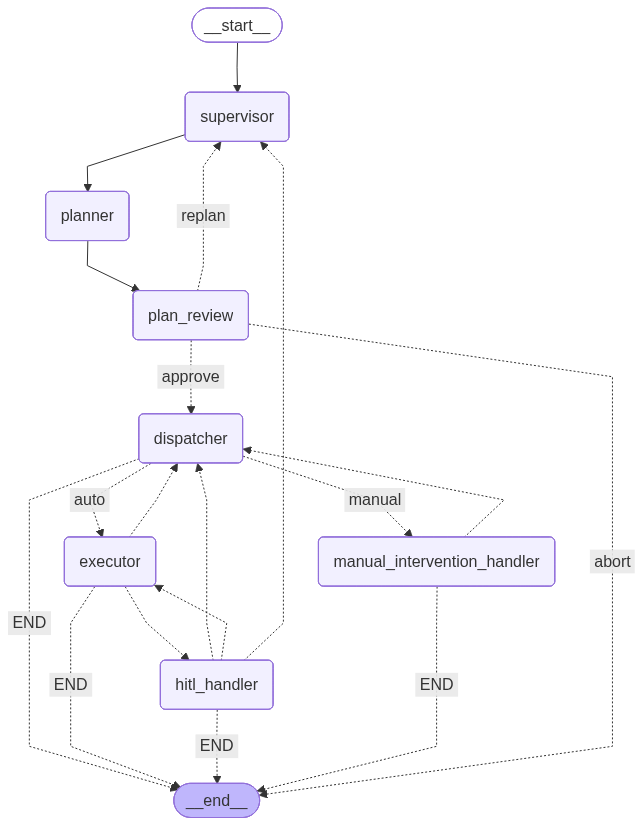

In [18]:
#  可视化
try:
    from IPython.display import Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization skipped:", e)
    print(graph.get_graph().draw_mermaid())

In [ ]:
import gradio as gr
import threading
import logging
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from SkiLib.robotcontext import RobotContext
import uuid

MAX_BUTTONS = 4

# Formatter for rendering LogRecord objects from log_queue into display strings
_gui_formatter = logging.Formatter("[%(levelname)s] %(name)s — %(message)s")

def _format_record(record: logging.LogRecord) -> str:
    return _gui_formatter.format(record)

def _drain_queue(q):
    """Discard stale log records left over from a previous run."""
    while not q.empty():
        try:
            q.get_nowait()
        except Exception:
            break

def _collect_queue(q, log_lines: list[str]) -> bool:
    """Drain all currently available records into log_lines. Returns True if any added."""
    added = False
    while not q.empty():
        try:
            record = q.get_nowait()
            log_lines.append(_format_record(record))
            added = True
        except Exception:
            break
    return added


# --- UI helpers ----------------------------------------------------------------
def get_button_updates(options):
    updates = []
    for i in range(MAX_BUTTONS):
        if i < len(options):
            updates.append(gr.update(value=options[i], visible=True))
        else:
            updates.append(gr.update(visible=False))
    return updates

def hide_buttons():
    return [gr.update(visible=False)] * MAX_BUTTONS


# --- Interrupt helpers ----------------------------------------------------------
def _check_for_interrupt(config, session, log_lines: list[str]):
    """Check graph state for interrupt and return final Gradio output tuple."""
    state = graph.get_state(config)
    log_text = "\n".join(log_lines)

    has_interrupt = (state.next
                     and state.tasks
                     and state.tasks[0].interrupts)
    if has_interrupt:
        interrupt_val = state.tasks[0].interrupts[0].value
        options      = interrupt_val.get("options", [])
        description  = interrupt_val.get("description", "")
        session["waiting"] = True
        log_text += f"\n[ 任务 ] {description}\n⏸ 等待人工确认..."
        return [log_text, session] + get_button_updates(options)

    session["waiting"] = False
    return [log_text, session] + hide_buttons()


# --- start_flow (streaming generator) ------------------------------------------
def start_flow(prompt, session):
    _drain_queue(log_queue)

    thread_id = str(uuid.uuid4())
    session["thread_id"] = thread_id
    config = {"configurable": {"thread_id": thread_id}}

    context = RobotContext()
    registry = SkillRegistry.instance()
    context.debug_skip_check = True  # skip IK/collision in sim

    global _supervisor_agent
    _supervisor_agent = None  # reset supervisor singleton

    _initial_state: GlobalState = {
        "messages":            [HumanMessage(content=prompt)],
        "todo_list":           [],
        "current_task":        {},
        "robot_state":         {},
        "halt_flag":           False,
        "halt_reason":         None,
        "last_result":         None,
        "intervention_action": None,
        "hitl_command":        None,
        "execution_log":       [],
    }

    done_event = threading.Event()

    def _run():
        try:
            graph.invoke(_initial_state, config=config)
        finally:
            done_event.set()

    threading.Thread(target=_run, daemon=True).start()

    log_lines: list[str] = []

    while not done_event.is_set():
        if _collect_queue(log_queue, log_lines):
            yield ["\n".join(log_lines), session] + hide_buttons()
        else:
            import time; time.sleep(0.05)

    _collect_queue(log_queue, log_lines)
    yield _check_for_interrupt(config, session, log_lines)


# --- handle_choice (streaming generator) ---------------------------------------
def handle_choice(choice, feedback, session):
    """Handle operator button click during HITL interrupt.

    When choice == "replan", the feedback textbox content is packaged as
    {"action": "replan", "feedback": <text>} so the plan_review node can
    forward the operator's comments to the supervisor for revision.
    For all other choices a plain string is passed (backward-compatible).
    """
    if not session.get("waiting"):
        yield ["", session] + hide_buttons()
        return

    _drain_queue(log_queue)

    config    = {"configurable": {"thread_id": session["thread_id"]}}
    done_event = threading.Event()

    if choice == "replan":
        payload = {"action": "replan", "feedback": (feedback or "").strip()}
    else:
        payload = choice

    def _run():
        try:
            graph.invoke(Command(resume=payload), config=config)
        finally:
            done_event.set()

    threading.Thread(target=_run, daemon=True).start()

    log_lines: list[str] = []

    while not done_event.is_set():
        if _collect_queue(log_queue, log_lines):
            yield ["\n".join(log_lines), session] + hide_buttons()
        else:
            import time; time.sleep(0.05)

    _collect_queue(log_queue, log_lines)
    yield _check_for_interrupt(config, session, log_lines)


# --- Gradio UI -----------------------------------------------------------------
with gr.Blocks(title="RoboSkiAgent HITL Demo") as demo:

    session_state = gr.State({})

    log_box = gr.Textbox(
        label="运行日志",
        lines=20,
        interactive=False,
        autoscroll=True,
    )

    with gr.Row():
        buttons = [gr.Button(visible=False) for _ in range(MAX_BUTTONS)]

    # Always-visible feedback box for replan comments.
    feedback_box = gr.Textbox(
        label="修改意见（选择 replan 时填写）",
        placeholder="例如：将任务3的 place_target 改为 Place_B，其余保持不变",
        lines=3,
    )

    with gr.Row():
        prompt_box = gr.Textbox(
            placeholder="输入任务描述...",
            show_label=False,
            scale=4,
        )
        start_btn = gr.Button("🚀 开始", variant="primary", scale=1)

    all_outputs = [log_box, session_state] + buttons

    start_btn.click(fn=start_flow,   inputs=[prompt_box, session_state], outputs=all_outputs)
    prompt_box.submit(fn=start_flow, inputs=[prompt_box, session_state], outputs=all_outputs)

    for btn in buttons:
        btn.click(fn=handle_choice, inputs=[btn, feedback_box, session_state], outputs=all_outputs)

demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


2026-03-27 16:46:04,412 [INFO] graph_test — [supervisor] Starting knowledge saturation...
2026-03-27 16:46:04,420 [INFO] graph_test — [supervisor] Agent built. Skills: ['DummySkill', 'PickAndPlace']
Exception in thread Thread-40 (_run):
Traceback (most recent call last):
  File "C:\Users\Yukun\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "C:\Users\Yukun\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Yukun\AppData\Local\Temp\ipykernel_48896\1722320931.py", line 103, in _run
  File "d:\code\skiagent\RoboSkiAgent\.venv\Lib\site-packages\langgraph\pregel\main.py", line 3292, in invoke
    for chunk in self.stream(
  File "d:\code\skiagent\RoboSkiAgent\.venv\Lib\site-packages\langgraph\pregel\main.py", line 2725, in stream
    for _ in runner.tick(
  File "d:\code\skiagent\RoboSkiAgent\.venv\Lib\site-packages\langgraph\pregel\_runner

In [15]:
# ── 端到端运行 ────────────────────────────────────────────────────────────────
from SkiLib.robotcontext import RobotContext
from SkiLib.registry import SkillRegistry

# 初始化 RobotContext（同时触发 SkillRegistry 自动扫描注册）
context = RobotContext()
registry = SkillRegistry.instance()
print("[init] Skills registered:", registry.list_skills())
context.debug_skip_check = True # IK和碰撞检查都没配置好，现在在模拟环境直接跳过。

# 重置 supervisor 单例（确保使用已注册的 SkillRegistry）
_supervisor_agent = None

_initial_state: GlobalState = {
    "messages":            [HumanMessage(content="把 Part_A_1 放到 目标点,然后把B_1放上去。人工上好螺丝帮你翻转之后把partC放上去。工件已配置完毕，可以直接执行自动任务。")],
    "todo_list":           [],
    "current_task":        {},
    "robot_state":         {},
    "halt_flag":           False,
    "halt_reason":         None,
    "last_result":         None,
    "intervention_action": None,
    "hitl_command":        None,
    "execution_log":       [],
}

_config = {"configurable": {"thread_id": "e2e-test-1"}}

print("\n=== Running end-to-end graph ===")
_final = graph.invoke(_initial_state, config=_config)

print("\n=== execution_log ===")
for line in _final.get("execution_log", []):
    print(" ", line)

print("\n=== todo_list remaining ===", _final.get("todo_list"))
print("=== current_task ===",         _final.get("current_task"))
print("=== halt_flag ===",            _final.get("halt_flag"))


[init] Skills registered: ['DummySkill', 'PickAndPlace']

=== Running end-to-end graph ===
[supervisor] Agent built. Skills: ['DummySkill', 'PickAndPlace']
[planner] Building plan via tool calls...


2026-03-26 15:35:07,969 [INFO] SkiLib.skills.pick_and_place — Step 1/8: MoveL to pick_approach 'App Pick Part A'...


[planner] Done: 4 tasks (1 manual)
[dispatcher] Dispatching t1 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_A_1', 'pick_approach': 'App Pick Part A', 'pick_target': 'Pick Part A', 'place_approach': 'App Place Part A ', 'place_target': 'Place Part A', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 15:35:08,861 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part A'...
2026-03-26 15:35:09,261 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_A_1'...
2026-03-26 15:35:09,361 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_A_1', attached='Part_A_1' via tool 'Gripper Extension'.
2026-03-26 15:35:09,364 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part A'...
2026-03-26 15:35:09,767 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part A '...
2026-03-26 15:35:10,380 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part A'...
2026-03-26 15:35:10,840 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_A_1'...
2026-03-26 15:35:10,892 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_A_1').
2026-03-26 15:35:10,941 [INFO] SkiLib.skills.pick_and_pla

[dispatcher] Dispatching t2 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_B_1', 'pick_approach': 'App Pick Part B', 'pick_target': 'Pick Part B', 'place_approach': 'App Place Part B', 'place_target': 'Place Part B', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 15:35:11,967 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part B'...
2026-03-26 15:35:12,517 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_B_1'...
2026-03-26 15:35:12,618 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_B_1', attached='Part_B_1' via tool 'Gripper Extension'.
2026-03-26 15:35:12,620 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part B'...
2026-03-26 15:35:13,126 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part B'...
2026-03-26 15:35:13,816 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part B'...
2026-03-26 15:35:14,274 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_B_1'...
2026-03-26 15:35:14,426 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_B_1').
2026-03-26 15:35:14,428 [INFO] SkiLib.skills.pick_and_plac

[dispatcher] Dispatching t3 (manual): 人工介入：请为 Part_A_1 + Part_B_1 组合体上好螺丝，然后将组合体翻转至指定方向，完成后确认继续。
[manual_handler] Handling manual task: 人工介入：请为 Part_A_1 + Part_B_1 组合体上好螺丝，然后将组合体翻转至指定方向，完成后确认继续。
[dispatcher] Dispatching t4 (auto): PickAndPlace
[executor] Running: PickAndPlace({'item': 'Part_C_1', 'pick_approach': 'App Pick Part C', 'pick_target': 'Pick Part C', 'place_approach': 'App Place Part C', 'place_target': 'Place Part C', 'transit_motion': 'MoveL', 'initial_motion': 'MoveL'})


2026-03-26 15:35:15,536 [INFO] SkiLib.skills.pick_and_place — Step 2/8: MoveL to pick_target 'Pick Part C'...
2026-03-26 15:35:16,090 [INFO] SkiLib.skills.pick_and_place — Step 3/8: Grasp 'Part_C_1'...
2026-03-26 15:35:16,188 [INFO] SkiLib.primitives.gripper — Grasp: intended='Part_C_1', attached='Part_C_1' via tool 'Gripper Extension'.
2026-03-26 15:35:16,190 [INFO] SkiLib.skills.pick_and_place — Step 4/8: MoveL depart to pick_approach 'App Pick Part C'...
2026-03-26 15:35:16,742 [INFO] SkiLib.skills.pick_and_place — Step 5/8: MoveL transit to place_approach 'App Place Part C'...
2026-03-26 15:35:17,442 [INFO] SkiLib.skills.pick_and_place — Step 6/8: MoveL to place_target 'Place Part C'...
2026-03-26 15:35:17,889 [INFO] SkiLib.skills.pick_and_place — Step 7/8: Release 'Part_C_1'...
2026-03-26 15:35:17,943 [INFO] SkiLib.primitives.gripper — Release: detached all objects from tool 'Gripper Extension' (expected item: 'Part_C_1').
2026-03-26 15:35:17,994 [INFO] SkiLib.skills.pick_and_plac

[dispatcher] No tasks in todo_list

=== execution_log ===
  [executor] t1 PickAndPlace -> SUCCESS
  [executor] t2 PickAndPlace -> SUCCESS
  [manual_handler] t3 -> COMPLETE (stub)
  [executor] t4 PickAndPlace -> SUCCESS

=== todo_list remaining === []
=== current_task === {}
=== halt_flag === False
